
## Example on Kernel Methods for Quantum Machine Learning

This tutorial is based on the Pennylane Kernel Tutorial from https://pennylane.ai/demos/tutorial_kernel_based_training. There, you can find more details on the comparison to a variational model. Furthermore, consider also the references in today's lecture notes. Based on https://arxiv.org/pdf/2101.11020, the Pennylane tutorial illustrates that the kernel-based training uses less quantum circuit evaluations than the variational one. If you're interested in the details, check out the tutorial and referenced papers. Here, we will focus only on the implementation of the quantum kernel and the evaluation of its performance.

In [103]:
%%capture
# install packages
!pip install torch
!pip install scikit-learn
!pip install pennylane
!pip install matplotlib

In [104]:
%%capture
# import packages
import numpy as np
import torch
from torch.nn.functional import relu
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pennylane as qp
from pennylane.templates import AngleEmbedding
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [105]:
# get the iris dataset, 100 samples, 2 features, 2 classes
X, y = load_iris(return_X_y=True)

X = X[:100]
y = y[:100]

# rescale to zero mean and unit variance due to the embedding (periodic angle embedding)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

# as in the lecture notes, we rescale the labels to be in the range [-1, 1]
# this is important for the cost function we will define later on
y_scaled = 2 * (y - 0.5)

# apply a train-test split to evaluate the performance of our model later on (usually 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

## Visualize the two-class Iris dataset

We observe that a linear decision boundary cannot separate the two classes exactly. This motivates the use of a non-linear model, such as a kernel method or a variational quantum model in this simple exemplary case.

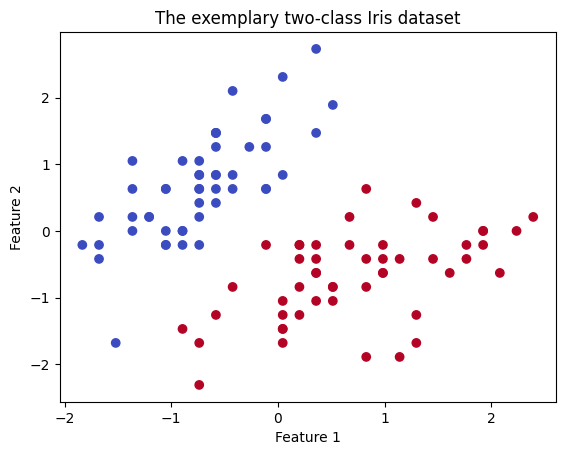

In [106]:
# visualize the dataset 
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_scaled, cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('The exemplary two-class Iris dataset')
plt.show()

## Let us now define a quantum kernel based on the angle embedding method 
We have discussed angle embedding in the last lecture. In the following, we will now define the qunatum kernel as a quantum circuit visualized below. We apply a specific unitary $U(x)$ to the initial state $|0\rangle$ (by $|0\rangle$ we always mean $|0 \dots 0\rangle$ = $|0\rangle \otimes \dots \otimes |0\rangle$ in the following) to encode the data, then apply the inverse of the unitary $U(x')$ to another data point, and finally measure the expectation value of the projector $|0\rangle\langle 0|$. This gives us the kernel value $k(x, x') = |\langle 0| U(x')^\dagger U(x) |0\rangle|^2$, with the mathematical expression summarized below. 


![caption](figures/kernel_circuit.png)

**Question**: What happens if the rotation-axis of the angle embedding is changed from 'Y' to 'X' or 'Z'? Compare the results. 

In [107]:
# as we use angle embedding later on to encode the data
# into a quantum state, we need to know the number of features (qubits) we have in our dataset
n_qubits = len(X_train[0])

# for this case we have 2 features, thus we need 2 qubits to encode the data with angle embedding
dev_kernel = qp.device("lightning.qubit", wires=n_qubits)

# this is the projector onto the |0> state, which we will use to define our quantum kernel
# thus, the projector is given by |0><0|, which is a matrix with a 1 in the top-left corner and 0s everywhere else
projector = np.zeros((2 ** n_qubits, 2 ** n_qubits))
projector[0, 0] = 1

@qp.qnode(dev_kernel)
def kernel(x1, x2):
    """The quantum kernel."""
    # first apply U(x1) to the |0> state, then apply U(x2)^\dagger, and finally measure the expectation value of the projector |0><0|.
    AngleEmbedding(x1, wires=range(n_qubits), rotation='Y')
    qp.adjoint(AngleEmbedding)(x2, wires=range(n_qubits), rotation='Y')
    return qp.expval(qp.Hermitian(projector, wires=range(n_qubits)))

**Question**: Can you implement an alternative quantum kernel and compare the results? Try to visualize for yourself how the data is embedded in the Hilbert space by the quantum kernel. Consider for example the Bloch sphere representation for a single qubit.

In [108]:
# check that the kernel is correctly defined
# for the kernel of a datapoint and itself, we should get 1 (or a value close to 1 due to numerical errors)
# assert that kernel(X_train[0], X_train[0]) is approx one with some numerical tolerance
assert np.isclose(kernel(X_train[0], X_train[0]), 1, atol=1e-6), 'Kernel of a datapoint with itself should be 1'

In [109]:
# define the kernel matrix for the training and test sets
def kernel_matrix(A, B):
    """Compute the kernel matrix with entries consisting of the kernel
       evaluated on pairwise data from classes A and B."""
    kernel_ab = np.array([[kernel(a, b) for b in B] for a in A])
    return kernel_ab

## Use the Support Vector Machine with Quantum Kernel
We use the support vector machine from the scikit-learn library, under https://scikit-learn.org/stable/modules/svm.html also a nice introduction to (classical) kernel methods can be found. We explicitly pass our quantum kernel to the SVM (kernel_matrix), which is implemented as a custom kernel.

In [110]:
svm = SVC(kernel=kernel_matrix).fit(X_train, y_train)

Evaluate performance of the quantum kernel SVM on the test set with $m$ test samples, where $\hat{y}_i$ is the predicted label for the $i$-th test sample and $y_i$ the true label for the $i$-th test sample, then we can compute the accuracy as:
$
\text{accuracy} = \frac{1}{m} \sum_{i=1}^{m} \mathbb{1}\!\left[\hat{y}_i = y_i\right]
$.

In [111]:
predictions = svm.predict(X_test)
print('accuracy on test set:', accuracy_score(predictions, y_test))

accuracy on test set: 1.0


## Visualize the predicted results on the test set

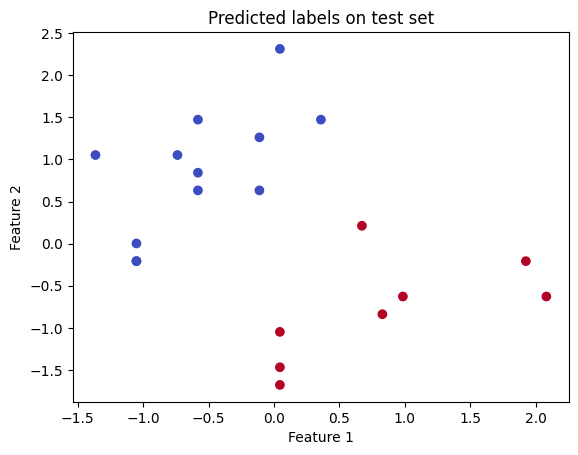

In [112]:
plt.figure()
plt.scatter(X_test[:, 0], X_test[:, 1], c=predictions, cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Predicted labels on test set')
plt.show()